# Classificazione del rischio di diabete

In questa fase ho costruito e confrontato due modelli di classificazione binaria: Logistic Regression e K-Nearest Neighbors (KNN). L'obiettivo è stimare se un record appartiene alla classe `Diabete_Esito = 0` oppure `Diabete_Esito = 1`. Il risultato è esclusivamente didattico e non costituisce una diagnosi medica.

## 1. Caricamento e preparazione dei dati

Ho ricaricato il dataset e mantenuto la stessa gestione degli zeri non plausibili usata nell'analisi esplorativa. In questo modo i due notebook restano coerenti.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

sns.set_theme(style='whitegrid')
url_dataset = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
colonne = ['Gravidanze','Glucosio','Pressione_Sanguigna','Spessore_Pelle','Insulina','BMI','Fattore_Ereditario_Diabete','Eta','Diabete_Esito']
df = pd.read_csv(url_dataset, names=colonne)
colonne_zeri = ['Glucosio','Pressione_Sanguigna','Spessore_Pelle','Insulina','BMI']
df[colonne_zeri] = df[colonne_zeri].replace(0, np.nan)
df.head()

,Gravidanze,Glucosio,Pressione_Sanguigna,Spessore_Pelle,Insulina,BMI,Fattore_Ereditario_Diabete,Eta,Diabete_Esito
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Separazione tra caratteristiche e target

Ho separato le variabili predittive dalla variabile da prevedere. `X` contiene le misure cliniche, mentre `y` contiene l'esito del diabete.

In [62]:
X = df.drop(columns='Diabete_Esito')
y = df['Diabete_Esito']
print('Dimensione X:', X.shape)
print('Distribuzione y:')
display(y.value_counts().sort_index())

Dimensione X: (768, 8)
Distribuzione y:


Diabete_Esito
0    500
1    268
Name: count, dtype: int64

## 3. Divisione tra training set e test set

Ho riservato il 20% dei dati al test finale. Il modello userà il training set per imparare e vedrà il test set soltanto alla fine, così la valutazione avverrà su dati mai utilizzati durante l'addestramento. `stratify=y` mantiene proporzioni simili tra le due classi.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training: {X_train.shape[0]} righe | Test: {X_test.shape[0]} righe')

Training: 614 righe | Test: 154 righe


## 4. Preprocessing e standardizzazione

Ho costruito una trasformazione riutilizzabile. Prima sostituisco gli zeri non plausibili con valori mancanti e imputo i mancanti con la mediana calcolata sul solo training set. Infine standardizzo le variabili, perché hanno scale molto diverse: senza questo passaggio l'insulina, che assume valori numericamente più grandi, peserebbe troppo nelle distanze usate da KNN. Applico la stessa trasformazione anche alla Logistic Regression per rendere il confronto coerente. La `Pipeline` evita di usare accidentalmente informazioni del test durante il training, riducendo il rischio di data leakage.

In [64]:
def sostituisci_zeri(frame):
    frame = frame.copy()
    frame[colonne_zeri] = frame[colonne_zeri].replace(0, np.nan)
    return frame

preprocessing = Pipeline([
    ('zeri_mancanti', FunctionTransformer(sostituisci_zeri, validate=False)),
    ('imputazione', ColumnTransformer([
        ('numeriche', SimpleImputer(strategy='median'), X.columns)
    ])),
    ('standardizzazione', StandardScaler())
])

## 5. Logistic Regression

Ho scelto la Logistic Regression come primo modello perché è una baseline adatta alla classificazione binaria e relativamente interpretabile. Produce una probabilità per la classe positiva, trasformata in classe usando la soglia predefinita di 0,5.

In [65]:
logistic_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('modello', LogisticRegression(max_iter=2000, random_state=42))
])
logistic_pipeline.fit(X_train, y_train)
logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

## 6. Valutazione della Logistic Regression

Ho calcolato accuracy, precision, recall e F1 per valutare le prestazioni con prospettive diverse. Ho aggiunto anche ROC-AUC come metrica supplementare: non sostituisce quelle principali, ma permette di valutare il modello a molte soglie diverse invece di considerare soltanto quella predefinita di 0,5. La curva ROC mostra il rapporto tra veri positivi e falsi positivi al variare della soglia; l'area sotto la curva, chiamata AUC, va da 0,5 (classificatore casuale) a 1 (classificatore perfetto). Un valore più alto indica che il modello riesce meglio a ordinare i casi positivi prima di quelli negativi. È utile qui perché il dataset non è perfettamente bilanciato e perché in un contesto medico la soglia può essere modificata per privilegiare il recall.

,Logistic Regression
Accuracy,0.708
Precision,0.600
Recall,0.500
F1-score,0.545
ROC-AUC,0.813


              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



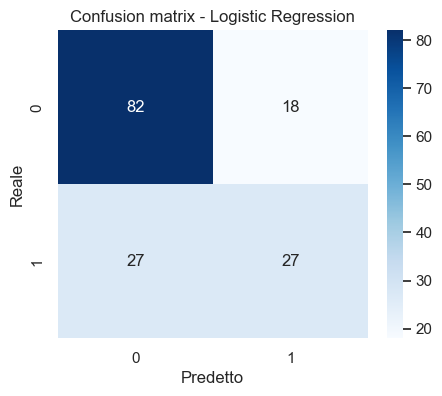

In [66]:
def metriche(y_vero, predizioni, probabilita):
    return {
        'Accuracy': accuracy_score(y_vero, predizioni),
        'Precision': precision_score(y_vero, predizioni, zero_division=0),
        'Recall': recall_score(y_vero, predizioni, zero_division=0),
        'F1-score': f1_score(y_vero, predizioni, zero_division=0),
        'ROC-AUC': roc_auc_score(y_vero, probabilita)
    }

metriche_logistic = metriche(y_test, logistic_pred, logistic_prob)
display(pd.Series(metriche_logistic).round(3).to_frame('Logistic Regression'))
print(classification_report(y_test, logistic_pred, zero_division=0))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, logistic_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix - Logistic Regression'); plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.show()

## 7. K-Nearest Neighbors

Ho aggiunto KNN come secondo modello perché offre un approccio diverso: per classificare un nuovo record considera le osservazioni più vicine nel dataset di training. Per questo modello la standardizzazione è indispensabile: senza di essa le variabili con valori numericamente più grandi dominerebbero la distanza.

,KNN
Accuracy,0.740
Precision,0.652
Recall,0.556
F1-score,0.600
ROC-AUC,0.807


              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



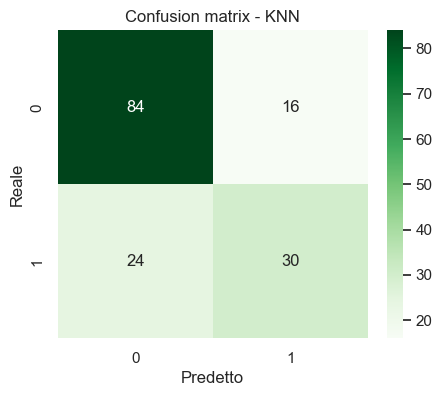

In [67]:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('modello', KNeighborsClassifier(n_neighbors=15))
])
knn_pipeline.fit(X_train, y_train)
knn_pred = knn_pipeline.predict(X_test)
knn_prob = knn_pipeline.predict_proba(X_test)[:, 1]
metriche_knn = metriche(y_test, knn_pred, knn_prob)
display(pd.Series(metriche_knn).round(3).to_frame('KNN'))
print(classification_report(y_test, knn_pred, zero_division=0))
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion matrix - KNN'); plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.show()

## 8. Cross-validation

Una singola divisione training/test può dipendere dalla casualità della suddivisione. Ho quindi usato una cross-validation stratificata a 5 parti sul training set. Ogni modello viene addestrato e validato più volte; la media e la deviazione standard descrivono meglio la stabilità della prestazione. Il test set resta escluso da questa fase. Ho mantenuto ROC-AUC tra gli indicatori come metrica supplementare: misura quanto il modello separa le due classi considerando molte soglie, mentre F1, precision e recall descrivono il comportamento alla soglia scelta. In questo notebook non ho ancora eseguito una ricerca automatica dei parametri: Logistic Regression usa il valore predefinito `C=1` con penalizzazione L2, mentre KNN usa `k=15`. La ricerca di valori alternativi e il confronto con caratteristiche polinomiali sono documentati nel notebook 03.

In [68]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1', 'roc_auc':'roc_auc'}

def risultati_cv(nome, modello):
    risultati = cross_validate(modello, X_train, y_train, cv=cv, scoring=scoring)
    return {'Modello': nome, **{metrica.upper(): f"{risultati['test_'+metrica].mean():.3f} ± {risultati['test_'+metrica].std():.3f}" for metrica in scoring}}

cv_logistic = risultati_cv('Logistic Regression', logistic_pipeline)
cv_knn = risultati_cv('KNN', knn_pipeline)
display(pd.DataFrame([cv_logistic, cv_knn]).set_index('Modello'))

,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
Modello,,,,,
Logistic Regression,0.788 ± 0.019,0.764 ± 0.060,0.575 ± 0.023,0.655 ± 0.024,0.843 ± 0.019
KNN,0.769 ± 0.033,0.719 ± 0.083,0.571 ± 0.067,0.632 ± 0.048,0.832 ± 0.030


## 9. Confronto diretto dei modelli

A questo punto confronto i due modelli sugli stessi dati di test. La tabella e il grafico a barre permettono di leggere subito quale modello ottiene il valore più alto per ciascuna metrica. Le confusion matrix viste nelle sezioni precedenti spiegano invece *da quali errori* derivano quei valori.

> **Come leggere i due grafici seguenti**
>
> - Il **grafico a barre** confronta direttamente accuracy, precision, recall e F1: per ogni metrica ci sono due barre, una per Logistic Regression e una per KNN.
> - Il **grafico ROC** contiene due linee: blu per Logistic Regression e arancione per KNN. La linea nera tratteggiata rappresenta un classificatore casuale, cioè un modello che indovina senza alcuna informazione. Una curva più vicina all'angolo in alto a sinistra indica una migliore separazione tra le due classi.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modello,,,,,
Logistic Regression,0.708,0.600,0.500,0.545,0.813
KNN,0.740,0.652,0.556,0.600,0.807


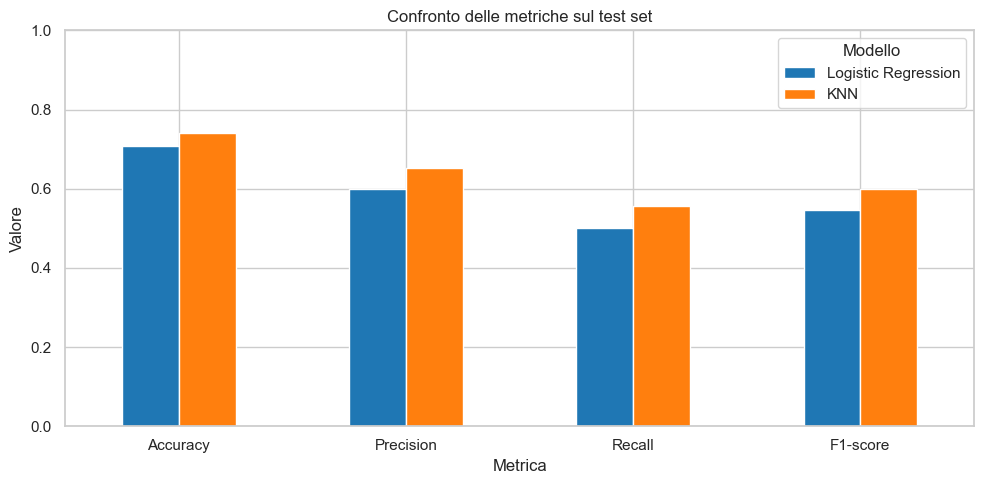

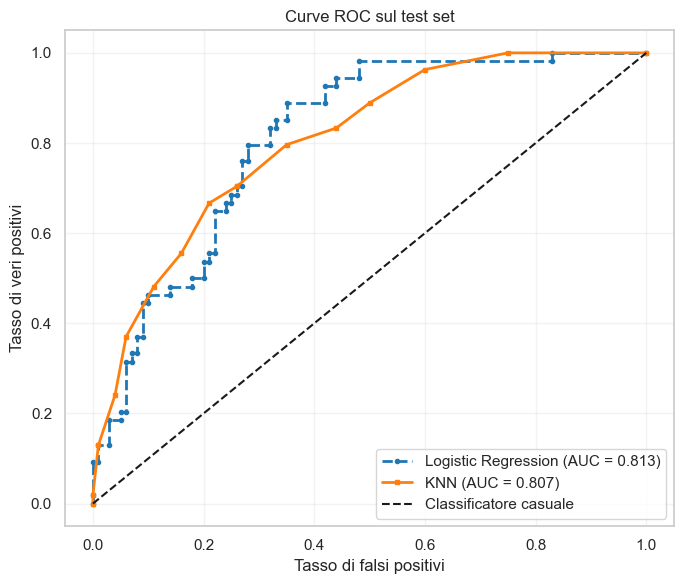

Baseline: prevedere sempre la classe più frequente darebbe accuracy=0.649
Interpretazione dei risultati sul test set:
- Logistic Regression: accuracy=0.708, precision=0.600, recall=0.500, F1=0.545, ROC-AUC=0.813
- KNN: accuracy=0.740, precision=0.652, recall=0.556, F1=0.600, ROC-AUC=0.807
Un recall più alto indica che il modello individua una quota maggiore dei casi positivi; una precision più alta indica meno falsi positivi tra le predizioni positive.


In [69]:
confronto = pd.DataFrame([
    {'Modello':'Logistic Regression', **metriche_logistic},
    {'Modello':'KNN', **metriche_knn}
]).set_index('Modello')
display(confronto.round(3))

confronto[['Accuracy', 'Precision', 'Recall', 'F1-score']].T.plot(
    kind='bar', figsize=(10, 5), color=['tab:blue', 'tab:orange']
)
plt.title('Confronto delle metriche sul test set')
plt.xlabel('Metrica'); plt.ylabel('Valore'); plt.ylim(0, 1)
plt.legend(title='Modello'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr_logistic, tpr_logistic, color='tab:blue', linestyle='--', marker='o', markersize=3, linewidth=2, label=f"Logistic Regression (AUC = {metriche_logistic['ROC-AUC']:.3f})")
plt.plot(fpr_knn, tpr_knn, color='tab:orange', linestyle='-', marker='s', markersize=3, linewidth=2, label=f"KNN (AUC = {metriche_knn['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Classificatore casuale')
plt.title('Curve ROC sul test set'); plt.xlabel('Tasso di falsi positivi'); plt.ylabel('Tasso di veri positivi')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Baseline: prevedere sempre la classe più frequente darebbe accuracy={baseline_accuracy:.3f}")
print('Interpretazione dei risultati sul test set:')
for nome, riga in confronto.iterrows():
    print(f"- {nome}: accuracy={riga['Accuracy']:.3f}, precision={riga['Precision']:.3f}, recall={riga['Recall']:.3f}, F1={riga['F1-score']:.3f}, ROC-AUC={riga['ROC-AUC']:.3f}")
print('Un recall più alto indica che il modello individua una quota maggiore dei casi positivi; una precision più alta indica meno falsi positivi tra le predizioni positive.')

## 10. Scelta del modello finale

Scelgo il modello finale osservando la ROC-AUC media della cross-validation e verificando che le altre metriche siano ragionevoli. Dai risultati ottenuti, Logistic Regression ha ROC-AUC media 0,843 e KNN 0,832: la differenza è contenuta, ma Logistic Regression risulta leggermente più stabile. Sul singolo test set KNN può invece ottenere accuracy o F1 più alte: questo non contraddice la cross-validation, ma mostra perché non è corretto scegliere sulla base di una sola suddivisione. Il modello scelto sarà poi addestrato sul training set e salvato insieme al preprocessing, così la Flask app potrà usare esattamente la stessa trasformazione sui dati inseriti dall'utente.

In [70]:
cv_auc = {
    'Logistic Regression': float(cross_validate(logistic_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')['test_score'].mean()),
    'KNN': float(cross_validate(knn_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')['test_score'].mean())
}
modello_finale = max(cv_auc, key=cv_auc.get)
print('ROC-AUC media cross-validation:', {k: round(v, 3) for k, v in cv_auc.items()})
print('Modello selezionato:', modello_finale)
print(f"Ho scelto {modello_finale} perché presenta la ROC-AUC media più alta nella cross-validation. Questa scelta va comunque letta insieme a recall, precision e F1: il valore più alto non significa che il modello sia clinicamente affidabile.")

ROC-AUC media cross-validation: {'Logistic Regression': 0.843, 'KNN': 0.832}
Modello selezionato: Logistic Regression
Ho scelto Logistic Regression perché presenta la ROC-AUC media più alta nella cross-validation. Questa scelta va comunque letta insieme a recall, precision e F1: il valore più alto non significa che il modello sia clinicamente affidabile.


## 11. Limiti dell'esperimento

Il dataset è relativamente piccolo e rappresenta una popolazione specifica, quindi i risultati non sono automaticamente generalizzabili ad altre popolazioni. Inoltre, un recall sul test set intorno a 0,50–0,56 significa che il modello non individua tutti i casi positivi: per questo le prestazioni sono utili come esercizio didattico, ma non sono sufficienti per un impiego clinico. Il modello può commettere falsi positivi e falsi negativi, che in un contesto clinico avrebbero conseguenze diverse. Le metriche ottenute descrivono questo dataset e questa procedura di suddivisione, ma non costituiscono una validazione clinica.

## 12. Conclusioni dell'esperimento

> **Valutazione complessiva**
>
> I modelli sono migliori della baseline: la previsione costante della classe più frequente raggiunge circa il 65% di accuracy, mentre sul test set KNN raggiunge il 74% e Logistic Regression il 71%. Il miglioramento esiste, ma non è sufficiente per parlare di diagnosi affidabile.

**Cosa concludo dai risultati.** Sul singolo test set KNN ha ottenuto accuracy 0,740 e F1-score 0,600, leggermente superiori a Logistic Regression (0,708 e 0,545). Nella cross-validation, invece, Logistic Regression ha ottenuto in media accuracy 0,788 ± 0,019, precision 0,764 ± 0,060, recall 0,575 ± 0,023, F1-score 0,655 ± 0,024 e ROC-AUC 0,843 ± 0,019. Questi valori non significano che la cross-validation abbia migliorato il modello: sono una stima più stabile delle sue prestazioni, calcolata su cinque suddivisioni diverse del training set. Il test set separato resta necessario come controllo finale su dati mai usati durante la selezione. Scelgo quindi Logistic Regression come modello finale, ma la differenza rispetto a KNN è piccola e non indica una superiorità assoluta in ogni metrica.

**Perché non considero il modello clinicamente adeguato.** Il recall positivo è moderato: 0,500 per Logistic Regression e 0,556 per KNN sul test set. Ciò significa che una quota rilevante di casi positivi non viene riconosciuta. Inoltre il dataset ha solo 768 record, otto caratteristiche cliniche e rappresenta una popolazione molto specifica; i valori mancanti e la variabilità dei dati limitano ulteriormente la capacità predittiva.

**Come potrei migliorarlo.** Nel notebook 3 ho verificato in modo controllato il parametro `C` della Logistic Regression, il grado delle caratteristiche polinomiali, il bilanciamento delle classi e il numero di vicini di KNN tramite cross-validation. Ho inoltre analizzato l'effetto di soglie diverse sul compromesso tra precision e recall. Questi esperimenti hanno migliorato e approfondito la configurazione del modello, ma non risolvono i limiti del dataset: per valutare una reale generalizzazione servirebbero più dati e una validazione su una popolazione indipendente. Anche dopo il tuning, le metriche ottenute descrivono soltanto questo dataset e questa procedura sperimentale. 